# Physicochemical Pollution 

## 1. Imports & Config

In [ ]:
import warnings, os, time
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   PowerTransformer, label_binarize)
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, f1_score, accuracy_score,
                             balanced_accuracy_score, matthews_corrcoef)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel, mutual_info_classif

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import (SMOTE, ADASYN, BorderlineSMOTE,
                                    SVMSMOTE)
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks

# Gradient boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna not found — install with: pip install optuna")

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not found — install with: pip install shap")

RANDOM_STATE = 42
N_SPLITS     = 10
N_JOBS       = -1

CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy'         : 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro'         : 'f1_macro',
    'f1_weighted'      : 'f1_weighted',
    'precision_macro'  : 'precision_macro',
    'recall_macro'     : 'recall_macro',
}

print("Libraries loaded.")

 Libraries loaded.


## 2. Load & EDA

In [ ]:
DATA_PATH = "dataset/d2.csv"
df = pd.read_csv(DATA_PATH)

# Drop non-predictive identifiers
df.drop(columns=[c for c in ['Timestamp', 'Location'] if c in df.columns],
        inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (1000, 9)


,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
0,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2
1,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2
2,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2
3,8.728748,0.736115,18.802153,6.543794,6.714160,0.003358,0.001058,0.005638,2
4,7.975335,19.151777,30.851902,4.370861,2.114614,0.006059,0.000124,0.001237,2


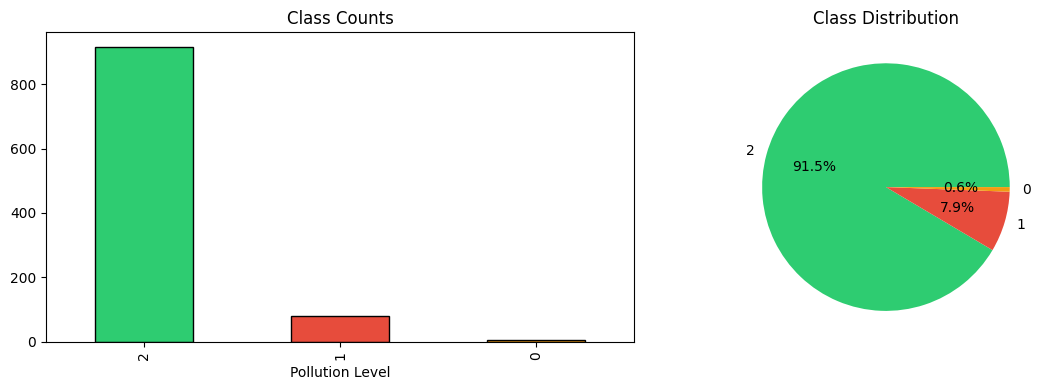

Pollution_Level
2    91.5
1     7.9
0     0.6
Name: proportion, dtype: float64

Imbalance ratio (max/min): 152.50x


In [3]:
# ── Class distribution ─────────────────────────────────────────────────────
class_counts = df['Pollution_Level'].value_counts()
class_pct    = df['Pollution_Level'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0],
                  color=['#2ECC71','#E74C3C','#F39C12'], edgecolor='black')
axes[0].set_title("Class Counts"); axes[0].set_xlabel("Pollution Level")

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#2ECC71','#E74C3C','#F39C12'])
axes[1].set_title("Class Distribution")
plt.tight_layout(); plt.show()

print(class_pct.round(2))
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")

In [4]:
# ── Missing-value analysis ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
miss_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Pct', ascending=False)

if miss_df.empty:
    print(" No missing values.")
else:
    print(miss_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    miss_df['Pct'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title("Missing Values %"); plt.tight_layout(); plt.show()

 No missing values.


In [5]:
# ── Statistical summary ────────────────────────────────────────────────────
feat_cols = [c for c in df.columns if c != 'Pollution_Level']

stat_df = pd.DataFrame({
    'Mean'     : df[feat_cols].mean(),
    'Std'      : df[feat_cols].std(),
    'Min'      : df[feat_cols].min(),
    'Max'      : df[feat_cols].max(),
    'Skewness' : df[feat_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis' : df[feat_cols].apply(lambda x: kurtosis(x.dropna()))
})

print(stat_df.round(3))

                    Mean    Std     Min     Max  Skewness  Kurtosis
pH                 7.251  1.025   5.516   8.998    -0.016    -1.219
Turbidity (NTU)   10.219  5.632   0.503  19.968    -0.021    -1.183
Temperature (°C)  24.967  5.757  15.000  34.991    -0.011    -1.219
DO (mg/L)          5.929  2.287   2.000   9.982     0.041    -1.162
BOD (mg/L)         5.483  2.604   1.008   9.994     0.043    -1.214
Lead (mg/L)        0.010  0.006   0.000   0.020     0.036    -1.200
Mercury (mg/L)     0.001  0.001   0.000   0.002     0.052    -1.153
Arsenic (mg/L)     0.010  0.006   0.001   0.020     0.107    -1.163


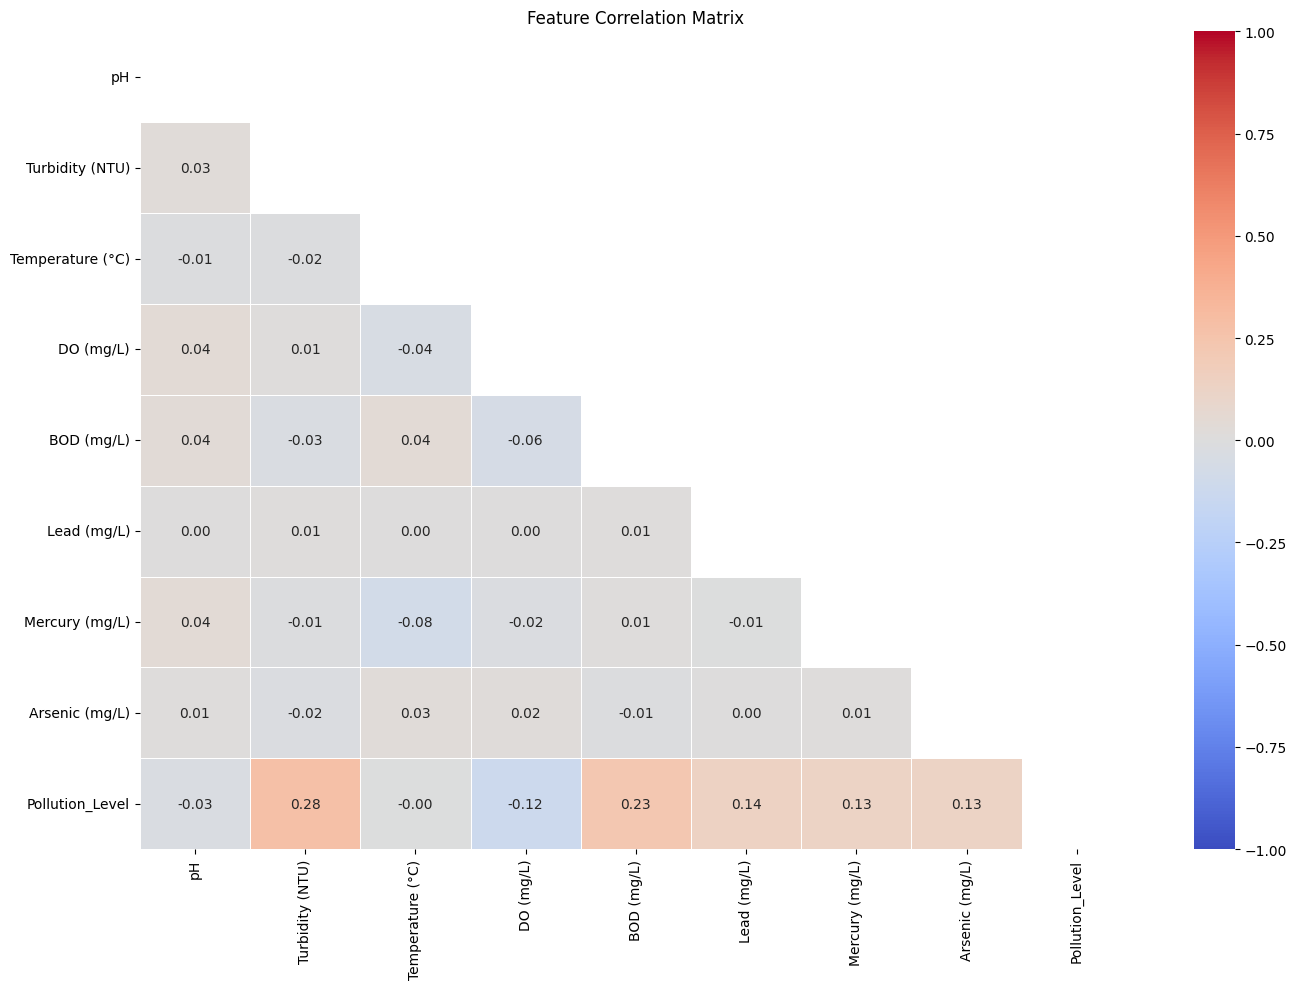

In [6]:
# ── Correlation heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            linewidths=0.5)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout(); plt.show()

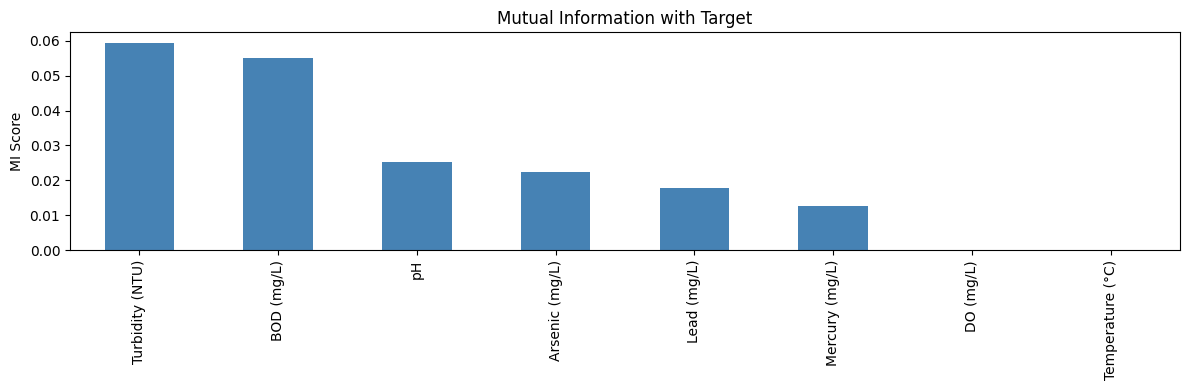

Turbidity (NTU)     0.0594
BOD (mg/L)          0.0551
pH                  0.0253
Arsenic (mg/L)      0.0223
Lead (mg/L)         0.0179
Mercury (mg/L)      0.0125
DO (mg/L)           0.0000
Temperature (°C)    0.0000
dtype: float64


In [7]:
# ── Mutual Information ─────────────────────────────────────────────────────
X_raw = df[feat_cols].copy()
y_raw = df['Pollution_Level'].copy()

# Fill NaN temporarily with median for MI computation
X_raw_filled = X_raw.fillna(X_raw.median())
mi_scores = mutual_info_classif(X_raw_filled, y_raw, random_state=RANDOM_STATE)
mi_df = pd.Series(mi_scores, index=feat_cols).sort_values(ascending=False)

mi_df.plot(kind='bar', color='steelblue', figsize=(12, 4))
plt.title("Mutual Information with Target")
plt.ylabel("MI Score"); plt.tight_layout(); plt.show()
print(mi_df.round(4))

## 3. Preprocessing & Advanced Feature Engineering

In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Domain-aware feature engineering for water quality data.
    Creates ratio, polynomial, and composite health-index features.
    """
    df = df.copy()
    feat_cols = [c for c in df.columns if c != 'Pollution_Level']

    # ── Polynomial features for top correlated features ──────────────────
    top_features = mi_df.head(5).index.tolist()
    for f in top_features:
        if f in df.columns:
            df[f"{f}_sq"]   = df[f] ** 2
            df[f"{f}_sqrt"] = np.sqrt(np.abs(df[f]))

    # ── Pairwise interaction ratios (top-4 features) ──────────────────────
    top4 = mi_df.head(4).index.tolist()
    for i in range(len(top4)):
        for j in range(i+1, len(top4)):
            a, b = top4[i], top4[j]
            if a in df.columns and b in df.columns:
                df[f"{a}_x_{b}"] = df[a] * df[b]
                denom = df[b].replace(0, np.nan)
                df[f"{a}_div_{b}"] = df[a] / denom

    # ── Heavy-metal composite index (sum of normalized heavy metals) ──────
    heavy_metals = [c for c in ['Lead (mg/L)', 'Arsenic (mg/L)',
                                 'Mercury (mg/L)', 'Cadmium (mg/L)',
                                 'Chromium (mg/L)'] if c in df.columns]
    if heavy_metals:
        df['heavy_metal_composite'] = df[heavy_metals].fillna(0).sum(axis=1)
        df['heavy_metal_max']       = df[heavy_metals].fillna(0).max(axis=1)

    # ── Organic load index ────────────────────────────────────────────────
    organic = [c for c in ['BOD (mg/L)', 'COD (mg/L)',
                            'Nitrates (mg/L)', 'Phosphates (mg/L)'] if c in df.columns]
    if organic:
        df['organic_load_composite'] = df[organic].fillna(0).sum(axis=1)

    # ── Physical condition index ──────────────────────────────────────────
    physical = [c for c in ['Turbidity (NTU)', 'pH', 'Conductivity (µS/cm)',
                             'Temperature (°C)'] if c in df.columns]
    if len(physical) >= 2:
        df['physical_index'] = df[physical].fillna(df[physical].median()).sum(axis=1)

    # ── Log-transform heavily skewed features (skewness > 1) ─────────────
    new_feat_cols = [c for c in df.columns if c != 'Pollution_Level']
    for c in new_feat_cols:
        col_skew = df[c].dropna().skew()
        if abs(col_skew) > 1:
            df[f"{c}_log1p"] = np.log1p(np.abs(df[c]))

    return df


df_eng = engineer_features(df)
print(f"Features after engineering: {df_eng.shape[1]-1}  (was {len(feat_cols)})")
df_eng.head(3)

Features after engineering: 39  (was 8)


,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level,Turbidity (NTU)_sq,...,pH_div_Arsenic (mg/L),heavy_metal_composite,heavy_metal_max,organic_load_composite,physical_index,Turbidity (NTU)_div_BOD (mg/L)_log1p,Turbidity (NTU)_div_Arsenic (mg/L)_log1p,BOD (mg/L)_x_Arsenic (mg/L)_log1p,BOD (mg/L)_div_Arsenic (mg/L)_log1p,pH_div_Arsenic (mg/L)_log1p
0,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2,209.331880,...,466.864573,0.023494,0.018769,2.478582,39.692351,1.922398,6.648825,0.045470,4.890798,6.148179
1,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2,3.631481,...,2016.578361,0.023892,0.019551,8.048453,36.830476,0.212504,6.243961,0.029409,7.683137,7.609653
2,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2,3.570234,...,1570.437778,0.024551,0.019291,2.102481,44.451341,0.641171,5.926400,0.010572,6.032933,7.359746


In [14]:
# ── Target / Feature split ────────────────────────────────────────────────
X_all = df_eng.drop('Pollution_Level', axis=1)
y_all = df_eng['Pollution_Level']

# ── KNN Imputation (fit on train; transform both) ─────────────────────────
imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                          columns=X_all.columns)

# ── Train / Test split (stratified 80/20) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_all,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print("Train class distribution:")
print(y_train.value_counts())

Train: (800, 39)  |  Test: (200, 39)
Train class distribution:
Pollution_Level
2    732
1     63
0      5
Name: count, dtype: int64


## 4. Helper Utilities

In [15]:
def summarise_cv(scores: dict, model_name: str) -> dict:
    """Summarise cross_validate results into a single dict row."""
    return {
        'Model'            : model_name,
        'Accuracy'         : scores['test_accuracy'].mean(),
        'Bal_Accuracy'     : scores['test_balanced_accuracy'].mean(),
        'F1_Macro'         : scores['test_f1_macro'].mean(),
        'F1_Weighted'      : scores['test_f1_weighted'].mean(),
        'Precision_Macro'  : scores['test_precision_macro'].mean(),
        'Recall_Macro'     : scores['test_recall_macro'].mean(),
        'F1_Macro_Std'     : scores['test_f1_macro'].std(),
    }


def evaluate_on_test(pipe, X_te, y_te, label='Model'):
    """Full evaluation on held-out test set."""
    y_pred  = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)

    print(f"\n{'='*60}")
    print(f"  TEST SET RESULTS — {label}")
    print(f"{'='*60}")
    print(f"  Accuracy         : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Balanced Accuracy: {balanced_accuracy_score(y_te, y_pred):.4f}")
    print(f"  F1 Macro         : {f1_score(y_te, y_pred, average='macro'):.4f}")
    print(f"  F1 Weighted      : {f1_score(y_te, y_pred, average='weighted'):.4f}")
    print(f"  MCC              : {matthews_corrcoef(y_te, y_pred):.4f}")
    print(f"  AUC-ROC (OvR)    : {roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro'):.4f}")
    print(f"{'='*60}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_te.unique()),
                yticklabels=sorted(y_te.unique()))
    plt.title(f'Confusion Matrix — {label}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    
    # Return statement removed to prevent printing arrays in Jupyter output


def plot_cv_results(cv_df: pd.DataFrame, title: str, top_n: int = 10):
    """Bar chart of CV F1-Macro for top-N models."""
    top = cv_df.head(top_n).copy()
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # F1 Macro
    axes[0].barh(top['Model'][::-1], top['F1_Macro'][::-1],
                 color='steelblue', edgecolor='black')
    axes[0].set_title(f"{title} — F1 Macro")
    axes[0].set_xlabel("CV F1 Macro")
    axes[0].set_xlim(0, 1)

    plt.tight_layout(); plt.show()


print(" Utilities ready.")

 Utilities ready.


# PHASE 1 — WITH Imbalance Handling
Techniques: SMOTE-ENN (combined over+under), class-weight balancing, calibrated probabilities, stacking ensemble + Optuna HPO.

### 4.1 Baseline Models (with SMOTE-ENN)

In [16]:
# ── Resampler: SMOTE-ENN (over + under combined) ──────────────────────────
smote_enn = SMOTEENN(random_state=RANDOM_STATE,
                     smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
                     enn=EditedNearestNeighbours())

# ── Base classifiers (all with cost-sensitive options where available) ─────
balanced_clfs = {
    "Logistic Regression"   : LogisticRegression(max_iter=3000, C=1.0,
                                                  solver='lbfgs',
                                                  class_weight='balanced',
                                                  # REMOVED: multi_class='auto', 
                                                  random_state=RANDOM_STATE),
    "K-Nearest Neighbors"   : KNeighborsClassifier(n_neighbors=5,
                                                    weights='distance',
                                                    metric='manhattan'),
    "Decision Tree"         : DecisionTreeClassifier(class_weight='balanced',
                                                      max_depth=15,
                                                      min_samples_leaf=3,
                                                      random_state=RANDOM_STATE),
    "Extra Tree"            : ExtraTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest"         : RandomForestClassifier(n_estimators=500,
                                                      class_weight='balanced_subsample',
                                                      max_features='sqrt',
                                                      min_samples_leaf=2,
                                                      random_state=RANDOM_STATE,
                                                      n_jobs=N_JOBS),
    "Extra Trees"           : ExtraTreesClassifier(n_estimators=500,
                                                    class_weight='balanced_subsample',
                                                    random_state=RANDOM_STATE,
                                                    n_jobs=N_JOBS),
    "Gradient Boosting"     : GradientBoostingClassifier(n_estimators=300,
                                                          learning_rate=0.05,
                                                          max_depth=5,
                                                          subsample=0.8,
                                                          random_state=RANDOM_STATE),
    "AdaBoost"              : AdaBoostClassifier(n_estimators=300,
                                                  learning_rate=0.1,
                                                  random_state=RANDOM_STATE),
    "XGBoost"               : XGBClassifier(n_estimators=500,
                                             learning_rate=0.05,
                                             max_depth=6,
                                             subsample=0.8,
                                             colsample_bytree=0.8,
                                             reg_alpha=0.1,
                                             reg_lambda=1.0,
                                             eval_metric='mlogloss',
                                             use_label_encoder=False,
                                             random_state=RANDOM_STATE,
                                             n_jobs=N_JOBS),
    "LightGBM"              : LGBMClassifier(n_estimators=700,
                                              learning_rate=0.03,
                                              num_leaves=63,
                                              min_child_samples=10,
                                              subsample=0.8,
                                              colsample_bytree=0.8,
                                              reg_alpha=0.05,
                                              reg_lambda=0.5,
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE,
                                              verbose=-1,
                                              n_jobs=N_JOBS),
    "CatBoost"              : CatBoostClassifier(iterations=1000,
                                                  learning_rate=0.05,
                                                  depth=6,
                                                  l2_leaf_reg=3,
                                                  border_count=128,
                                                  loss_function='MultiClass',
                                                  auto_class_weights='Balanced',
                                                  verbose=0,
                                                  random_seed=RANDOM_STATE),
    "SVM"                   : SVC(C=10, kernel='rbf', gamma='scale',
                                   class_weight='balanced',
                                   probability=True,
                                   random_state=RANDOM_STATE),
    "Naive Bayes"           : GaussianNB(var_smoothing=1e-8),
    "MLP (Neural Network)"  : MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32),
                                             activation='relu',
                                             batch_size=64,
                                             learning_rate='adaptive',
                                             max_iter=1000,
                                             early_stopping=True,
                                             n_iter_no_change=30,
                                             random_state=RANDOM_STATE),
}

print(f" {len(balanced_clfs)} base classifiers defined.")

 14 base classifiers defined.


In [17]:
# ── Phase 1: CV with SMOTE-ENN resampling ────────────────────────────────
phase1_results = []

for name, clf in balanced_clfs.items():
    t0 = time.time()
    print(f"   Running: {name}")

    pipe = ImbPipeline([
        ('scaler'  , RobustScaler()),        # robust to outliers
        ('resample', smote_enn),             # combined over+under sampling
        ('clf'     , clf)
    ])

    scores = cross_validate(pipe, X_train, y_train,
                            cv=CV, scoring=SCORING,
                            n_jobs=N_JOBS, error_score='raise')

    row = summarise_cv(scores, name)
    phase1_results.append(row)
    elapsed = time.time() - t0
    print(f"     → F1 Macro: {row['F1_Macro']:.4f} ± {row['F1_Macro_Std']:.4f} | "
          f"[{elapsed:.1f}s]")

phase1_df = (pd.DataFrame(phase1_results)
               .sort_values('F1_Macro', ascending=False)
               .reset_index(drop=True))
print("\n Phase 1 CV complete.")

   Running: Logistic Regression
     → F1 Macro: 0.6048 ± 0.1320 | [0.5s]
   Running: K-Nearest Neighbors
     → F1 Macro: 0.5584 ± 0.1325 | [0.3s]
   Running: Decision Tree
     → F1 Macro: 0.6838 ± 0.1556 | [0.5s]
   Running: Extra Tree
     → F1 Macro: 0.5983 ± 0.1581 | [0.3s]
   Running: Random Forest
     → F1 Macro: 0.6949 ± 0.1673 | [19.2s]
   Running: Extra Trees
     → F1 Macro: 0.7104 ± 0.1696 | [6.6s]
   Running: Gradient Boosting
     → F1 Macro: 0.7358 ± 0.1594 | [153.4s]
   Running: AdaBoost
     → F1 Macro: 0.5815 ± 0.1258 | [19.6s]
   Running: XGBoost
     → F1 Macro: 0.7218 ± 0.1648 | [9.7s]
   Running: LightGBM
     → F1 Macro: 0.7137 ± 0.1561 | [11.4s]
   Running: CatBoost
     → F1 Macro: 0.7564 ± 0.1845 | [33.3s]
   Running: SVM
     → F1 Macro: 0.6305 ± 0.1591 | [0.9s]
   Running: Naive Bayes
     → F1 Macro: 0.6156 ± 0.1655 | [0.2s]
   Running: MLP (Neural Network)
     → F1 Macro: 0.6405 ± 0.1719 | [11.5s]

 Phase 1 CV complete.



 Phase 1 Results (sorted by F1 Macro):
               Model  Accuracy  Bal_Accuracy  F1_Macro  F1_Weighted  F1_Macro_Std
            CatBoost   0.94625      0.862158  0.756435     0.951707      0.184510
   Gradient Boosting   0.95375      0.850512  0.735849     0.957221      0.159365
             XGBoost   0.94500      0.821887  0.721766     0.949804      0.164838
            LightGBM   0.93875      0.839039  0.713738     0.945110      0.156086
         Extra Trees   0.92125      0.798665  0.710356     0.929714      0.169619
       Random Forest   0.93375      0.816864  0.694938     0.940118      0.167342
       Decision Tree   0.92625      0.783641  0.683760     0.933535      0.155613
MLP (Neural Network)   0.89250      0.775074  0.640545     0.909565      0.171920
                 SVM   0.89750      0.785960  0.630471     0.911418      0.159065
         Naive Bayes   0.85750      0.776536  0.615562     0.883552      0.165521
 Logistic Regression   0.86375      0.857531  0.604811    

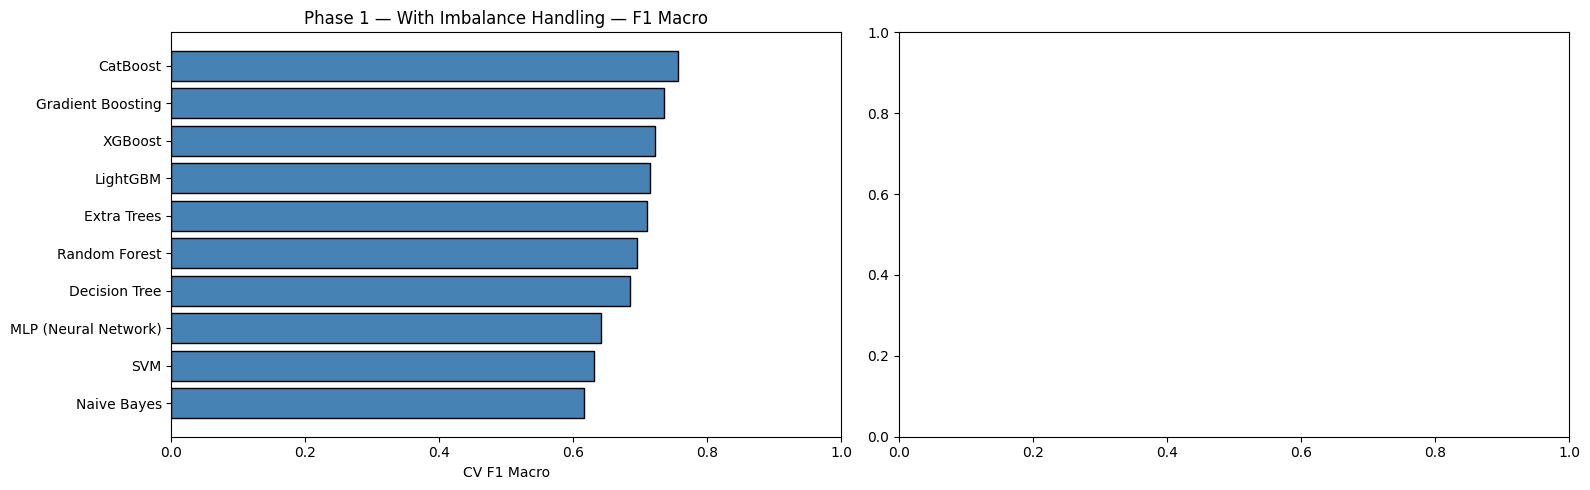

In [18]:
print("\n Phase 1 Results (sorted by F1 Macro):")
display_cols = ['Model','Accuracy','Bal_Accuracy','F1_Macro',
                'F1_Weighted','F1_Macro_Std']
print(phase1_df[display_cols].to_string(index=False))

plot_cv_results(phase1_df, "Phase 1 — With Imbalance Handling")

### 4.2 Optuna Hyperparameter Optimisation (Top-3 Models)

In [19]:
if not OPTUNA_AVAILABLE:
    print("  Optuna not installed — skipping HPO. Install: pip install optuna")
else:
    top3_names = phase1_df.head(3)['Model'].tolist()
    print(f" Tuning top-3 models: {top3_names}")

    # ── ROBUST RESAMPLER FOR OPTUNA ────────────────────────────────────────
    # Use SMOTE with k_neighbors=2 to handle very small classes (e.g., 3-4 samples) 
    # inside CV splits without crashing or deleting classes.
    smote_optuna = SMOTE(random_state=RANDOM_STATE, k_neighbors=2)
    # ─────────────────────────────────────────────────────────────────────────

    def objective_lgbm(trial):
        params = {
            'n_estimators'   : trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate'  : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves'     : trial.suggest_int('num_leaves', 20, 200),
            'max_depth'      : trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample'      : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'      : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'     : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        }
        clf = LGBMClassifier(**params, class_weight='balanced',
                              random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS)
        pipe = ImbPipeline([('scaler', RobustScaler()),
                             ('resample', smote_optuna),  # <--- UPDATED
                             ('clf', clf)])
        cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, scores, average='macro')

    def objective_xgb(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 12),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        clf = XGBClassifier(**params, eval_metric='mlogloss',
                             use_label_encoder=False,
                             random_state=RANDOM_STATE, n_jobs=N_JOBS)
        pipe = ImbPipeline([('scaler', RobustScaler()),
                             ('resample', smote_optuna),  # <--- UPDATED
                             ('clf', clf)])
        cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, scores, average='macro')

    def objective_catboost(trial):
        params = {
            'iterations'  : trial.suggest_int('iterations', 200, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth'        : trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg'  : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'border_count' : trial.suggest_int('border_count', 32, 255),
        }
        clf = CatBoostClassifier(**params, loss_function='MultiClass',
                                  auto_class_weights='Balanced',
                                  verbose=0, random_seed=RANDOM_STATE)
        pipe = ImbPipeline([('scaler', RobustScaler()),
                             ('resample', smote_optuna),  # <--- UPDATED
                             ('clf', clf)])
        cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, scores, average='macro')

    OBJECTIVE_MAP = {
        'LightGBM' : objective_lgbm,
        'XGBoost'  : objective_xgb,
        'CatBoost' : objective_catboost,
    }

    best_params_phase1 = {}
    N_TRIALS = 5

    for model_name in top3_names:
        if model_name not in OBJECTIVE_MAP:
            print(f"    No Optuna objective for {model_name} — skipping.")
            continue
        print(f"\n Optimising: {model_name} ({N_TRIALS} trials)")
        study = optuna.create_study(direction='maximize',
                                    study_name=f"{model_name}_phase1")
        study.optimize(OBJECTIVE_MAP[model_name],
                       n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)
        best_params_phase1[model_name] = study.best_params
        print(f"   Best F1 Macro: {study.best_value:.4f}")
        print(f"   Best params:   {study.best_params}")

    print("\n Phase 1 HPO complete.")

 Tuning top-3 models: ['CatBoost', 'Gradient Boosting', 'XGBoost']

 Optimising: CatBoost (5 trials)


Best trial: 2. Best value: 0.881078: 100%|██████████| 5/5 [01:21<00:00, 16.25s/it]


   Best F1 Macro: 0.8811
   Best params:   {'iterations': 821, 'learning_rate': 0.1304338395115004, 'depth': 6, 'l2_leaf_reg': 0.00224007042022507, 'border_count': 68}
    No Optuna objective for Gradient Boosting — skipping.

 Optimising: XGBoost (5 trials)


Best trial: 0. Best value: 0.780369: 100%|██████████| 5/5 [00:21<00:00,  4.27s/it]

   Best F1 Macro: 0.7804
   Best params:   {'n_estimators': 321, 'learning_rate': 0.011630496843452073, 'max_depth': 3, 'subsample': 0.7134641664699937, 'colsample_bytree': 0.9580468052817244, 'reg_alpha': 0.016485468371573102, 'reg_lambda': 0.7220173168177442, 'gamma': 4.615587828056032, 'min_child_weight': 10}

 Phase 1 HPO complete.


### 4.3 Stacking Ensemble (Phase 1)

In [20]:
# ── Build tuned base learners for the stack ───────────────────────────────
lgbm_tuned_p1 = LGBMClassifier(
    **(best_params_phase1.get('LightGBM', {})),
    class_weight='balanced', random_state=RANDOM_STATE,
    verbose=-1, n_jobs=N_JOBS
) if OPTUNA_AVAILABLE and 'LightGBM' in best_params_phase1 else balanced_clfs['LightGBM']

xgb_tuned_p1  = XGBClassifier(
    **(best_params_phase1.get('XGBoost', {})),
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
) if OPTUNA_AVAILABLE and 'XGBoost' in best_params_phase1 else balanced_clfs['XGBoost']

cat_tuned_p1  = CatBoostClassifier(
    **(best_params_phase1.get('CatBoost', {})),
    loss_function='MultiClass', auto_class_weights='Balanced',
    verbose=0, random_seed=RANDOM_STATE
) if OPTUNA_AVAILABLE and 'CatBoost' in best_params_phase1 else balanced_clfs['CatBoost']

# ── Stacking: diverse base learners + LR meta-learner ────────────────────
stack_estimators_p1 = [
    ('lgbm'  , lgbm_tuned_p1),
    ('xgb'   , xgb_tuned_p1),
    ('cat'   , cat_tuned_p1),
    ('rf'    , balanced_clfs['Random Forest']),
    ('et'    , balanced_clfs['Extra Trees']),
    ('svm'   , balanced_clfs['SVM']),
    ('mlp'   , balanced_clfs['MLP (Neural Network)']),
]

# FIXED: Removed 'multi_class' argument
meta_lr = CalibratedClassifierCV(
    LogisticRegression(max_iter=3000, C=5.0, 
                       # REMOVED: multi_class='auto'
                       random_state=RANDOM_STATE),
    method='isotonic', cv=5
)

stacking_p1 = StackingClassifier(
    estimators=stack_estimators_p1,
    final_estimator=meta_lr,
    cv=5,
    stack_method='predict_proba',
    passthrough=True,          # pass original features to meta-learner too
    n_jobs=N_JOBS
)

# UPDATED: Switched to SMOTE only to prevent class loss/dimension mismatch errors
smote_stack = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

stack_pipe_p1 = ImbPipeline([
    ('scaler'  , RobustScaler()),
    ('resample', smote_stack),  # Using SMOTE only
    ('clf'     , stacking_p1)
])

print(" Stacking ensemble defined. Training...")
stack_pipe_p1.fit(X_train, y_train)
print(" Stacking ensemble trained.")

 Stacking ensemble defined. Training...
 Stacking ensemble trained.



--- Best Single Model: CatBoost ---

  TEST SET RESULTS — CatBoost (Phase 1)
  Accuracy         : 0.9550
  Balanced Accuracy: 0.9266
  F1 Macro         : 0.7151
  F1 Weighted      : 0.9604
  MCC              : 0.7552
  AUC-ROC (OvR)    : 0.9939

Classification Report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.72      0.81      0.76        16
           2       0.99      0.97      0.98       183

    accuracy                           0.95       200
   macro avg       0.66      0.93      0.72       200
weighted avg       0.97      0.95      0.96       200



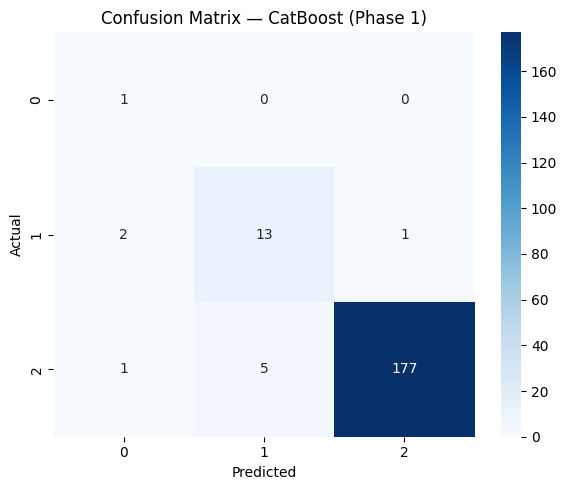


--- Stacking Ensemble ---

  TEST SET RESULTS — Stacking Ensemble (Phase 1)
  Accuracy         : 0.9550
  Balanced Accuracy: 0.8125
  F1 Macro         : 0.6966
  F1 Weighted      : 0.9490
  MCC              : 0.6763
  AUC-ROC (OvR)    : 0.9166

Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.44      0.61        16
           2       0.96      1.00      0.98       183

    accuracy                           0.95       200
   macro avg       0.77      0.81      0.70       200
weighted avg       0.96      0.95      0.95       200



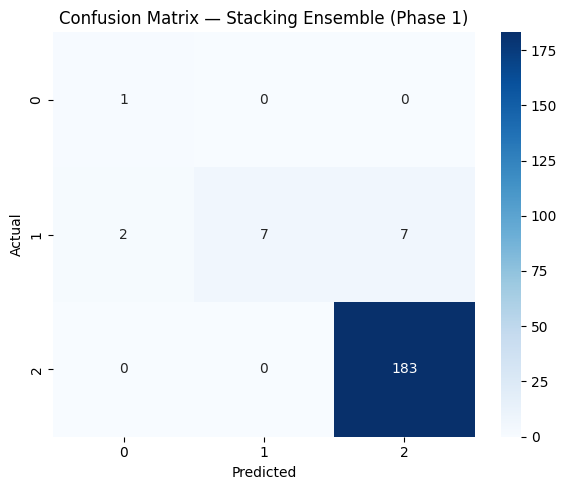

In [21]:
# ── Final test-set evaluation (Phase 1 — best single + stacking) ──────────
best_single_p1_name = phase1_df.iloc[0]['Model']
best_single_clf_p1  = balanced_clfs[best_single_p1_name]

best_single_pipe_p1 = ImbPipeline([
    ('scaler'  , RobustScaler()),
    ('resample', smote_enn),
    ('clf'     , best_single_clf_p1)
])
best_single_pipe_p1.fit(X_train, y_train)

print(f"\n--- Best Single Model: {best_single_p1_name} ---")
evaluate_on_test(best_single_pipe_p1, X_test, y_test,
                 label=f"{best_single_p1_name} (Phase 1)")

print("\n--- Stacking Ensemble ---")
evaluate_on_test(stack_pipe_p1, X_test, y_test,
                 label="Stacking Ensemble (Phase 1)")

### 4.4 SHAP Explainability (Phase 1 Best Model)

In [ ]:
if SHAP_AVAILABLE:
    # Use the best single model if it's tree-based; else use RF
    shap_clf_name = best_single_p1_name if 'Forest' in best_single_p1_name \
                    or 'Boost' in best_single_p1_name \
                    or 'LGBM' in best_single_p1_name \
                    else 'LightGBM'

    shap_pipe = ImbPipeline([
        ('scaler'  , RobustScaler()),
        ('resample', smote_enn),
        ('clf'     , balanced_clfs[shap_clf_name])
    ])
    shap_pipe.fit(X_train, y_train)

    # Scale test data with the fitted scaler
    X_test_scaled = shap_pipe.named_steps['scaler'].transform(X_test)
    X_test_df_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    tree_model = shap_pipe.named_steps['clf']
    explainer  = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(X_test_df_scaled)

    plt.figure(figsize=(12, 7))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_test_df_scaled,
                          plot_type='bar', show=False)
    else:
        shap.summary_plot(shap_values, X_test_df_scaled,
                          plot_type='bar', show=False)
    plt.title(f"SHAP Feature Importance — {shap_clf_name} (Phase 1)")
    plt.tight_layout(); plt.show()
else:
    print("  SHAP not available — install with: pip install shap")

---
#  PHASE 2 — WITHOUT Imbalance Handling
Raw class distribution. Models rely only on internal cost-sensitive mechanisms (class_weight, scale_pos_weight). No SMOTE / resampling applied.

### 5.1 Baseline Models (No Resampling)

In [23]:
phase2_results = []

for name, clf in balanced_clfs.items():
    t0 = time.time()
    print(f"   Running: {name}")

    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('clf'   , clf)
    ])

    scores = cross_validate(pipe, X_train, y_train,
                            cv=CV, scoring=SCORING,
                            n_jobs=N_JOBS, error_score='raise')

    row = summarise_cv(scores, name)
    phase2_results.append(row)
    elapsed = time.time() - t0
    print(f"     → F1 Macro: {row['F1_Macro']:.4f} ± {row['F1_Macro_Std']:.4f} | "
          f"[{elapsed:.1f}s]")

phase2_df = (pd.DataFrame(phase2_results)
               .sort_values('F1_Macro', ascending=False)
               .reset_index(drop=True))
print("\n Phase 2 CV complete.")

   Running: Logistic Regression
     → F1 Macro: 0.6235 ± 0.1437 | [0.3s]
   Running: K-Nearest Neighbors
     → F1 Macro: 0.5947 ± 0.1845 | [0.2s]
   Running: Decision Tree
     → F1 Macro: 0.7531 ± 0.1740 | [0.2s]
   Running: Extra Tree
     → F1 Macro: 0.5509 ± 0.1015 | [0.1s]
   Running: Random Forest
     → F1 Macro: 0.7613 ± 0.1786 | [9.3s]
   Running: Extra Trees
     → F1 Macro: 0.5864 ± 0.0958 | [4.8s]
   Running: Gradient Boosting
     → F1 Macro: 0.7924 ± 0.1921 | [58.2s]
   Running: AdaBoost
     → F1 Macro: 0.5532 ± 0.1698 | [9.1s]
   Running: XGBoost
     → F1 Macro: 0.7943 ± 0.1895 | [6.7s]
   Running: LightGBM
     → F1 Macro: 0.8623 ± 0.1705 | [9.6s]
   Running: CatBoost
     → F1 Macro: 0.8758 ± 0.1578 | [30.6s]
   Running: SVM
     → F1 Macro: 0.6327 ± 0.1603 | [0.4s]
   Running: Naive Bayes
     → F1 Macro: 0.6236 ± 0.1529 | [0.1s]
   Running: MLP (Neural Network)
     → F1 Macro: 0.6063 ± 0.1468 | [6.1s]

 Phase 2 CV complete.



 Phase 2 Results (sorted by F1 Macro):
               Model  Accuracy  Bal_Accuracy  F1_Macro  F1_Weighted  F1_Macro_Std
            CatBoost   0.99000      0.906973  0.875751     0.989175      0.157770
            LightGBM   0.98625      0.862528  0.862308     0.984078      0.170480
             XGBoost   0.98500      0.790079  0.794273     0.981572      0.189545
   Gradient Boosting   0.98375      0.796081  0.792353     0.980529      0.192083
       Random Forest   0.97500      0.753351  0.761274     0.971244      0.178642
       Decision Tree   0.96750      0.819807  0.753084     0.967758      0.174040
                 SVM   0.89375      0.778797  0.632691     0.908538      0.160331
         Naive Bayes   0.87250      0.809320  0.623638     0.895341      0.152928
 Logistic Regression   0.87625      0.845164  0.623450     0.898998      0.143729
MLP (Neural Network)   0.93500      0.605282  0.606279     0.925412      0.146833
 K-Nearest Neighbors   0.91875      0.595298  0.594743    

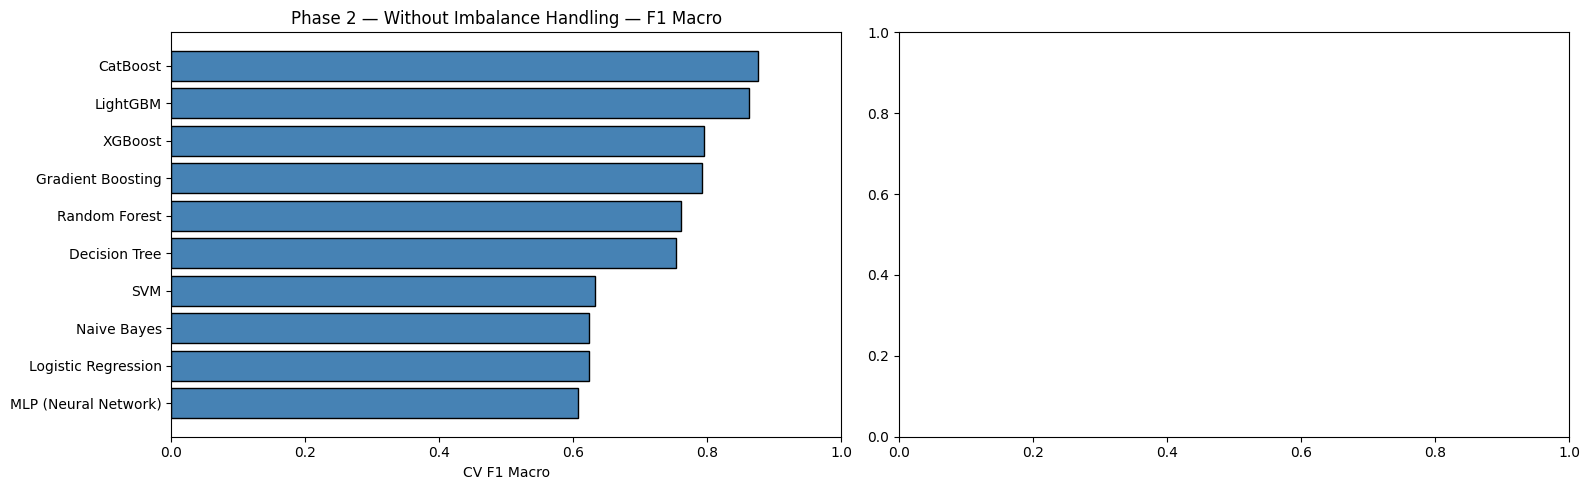

In [24]:
print("\n Phase 2 Results (sorted by F1 Macro):")
print(phase2_df[display_cols].to_string(index=False))

plot_cv_results(phase2_df, "Phase 2 — Without Imbalance Handling")

### 5.2 Optuna HPO (Phase 2)

In [25]:
if not OPTUNA_AVAILABLE:
    print("  Optuna not installed — skipping HPO.")
else:
    top3_names_p2 = phase2_df.head(3)['Model'].tolist()
    print(f" Tuning top-3 models (Phase 2): {top3_names_p2}")

    # Re-define objectives without resampler
    def objective_lgbm_p2(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
            'max_depth'        : trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        }
        clf = LGBMClassifier(**params, class_weight='balanced',
                              random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS)
        pipe = Pipeline([('scaler', RobustScaler()), ('clf', clf)])
        cv3  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        pred = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, pred, average='macro')

    def objective_xgb_p2(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 12),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        clf  = XGBClassifier(**params, eval_metric='mlogloss',
                              use_label_encoder=False,
                              random_state=RANDOM_STATE, n_jobs=N_JOBS)
        pipe = Pipeline([('scaler', RobustScaler()), ('clf', clf)])
        cv3  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        pred = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, pred, average='macro')

    def objective_cat_p2(trial):
        params = {
            'iterations'   : trial.suggest_int('iterations', 200, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth'        : trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg'  : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'border_count' : trial.suggest_int('border_count', 32, 255),
        }
        clf  = CatBoostClassifier(**params, loss_function='MultiClass',
                                   auto_class_weights='Balanced',
                                   verbose=0, random_seed=RANDOM_STATE)
        pipe = Pipeline([('scaler', RobustScaler()), ('clf', clf)])
        cv3  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        pred = cross_val_predict(pipe, X_train, y_train, cv=cv3, method='predict')
        return f1_score(y_train, pred, average='macro')

    OBJ_MAP_P2 = {'LightGBM': objective_lgbm_p2,
                  'XGBoost' : objective_xgb_p2,
                  'CatBoost': objective_cat_p2}

    best_params_phase2 = {}
    for model_name in top3_names_p2:
        if model_name not in OBJ_MAP_P2:
            continue
        print(f"\n Optimising: {model_name} ({N_TRIALS} trials)")
        study = optuna.create_study(direction='maximize',
                                    study_name=f"{model_name}_phase2")
        study.optimize(OBJ_MAP_P2[model_name],
                       n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)
        best_params_phase2[model_name] = study.best_params
        print(f"   Best F1 Macro: {study.best_value:.4f}")
        print(f"   Best params:   {study.best_params}")

    print("\n Phase 2 HPO complete.")

 Tuning top-3 models (Phase 2): ['CatBoost', 'LightGBM', 'XGBoost']

 Optimising: CatBoost (5 trials)


Best trial: 4. Best value: 0.879097: 100%|██████████| 5/5 [04:00<00:00, 48.07s/it]


   Best F1 Macro: 0.8791
   Best params:   {'iterations': 1068, 'learning_rate': 0.01735870540924567, 'depth': 7, 'l2_leaf_reg': 1.096744518053816, 'border_count': 167}

 Optimising: LightGBM (5 trials)


Best trial: 1. Best value: 0.825993: 100%|██████████| 5/5 [00:13<00:00,  2.67s/it]


   Best F1 Macro: 0.8260
   Best params:   {'n_estimators': 530, 'learning_rate': 0.04915421060119209, 'num_leaves': 56, 'max_depth': 9, 'min_child_samples': 19, 'subsample': 0.5572179349924531, 'colsample_bytree': 0.5078061287634585, 'reg_alpha': 0.0011557380583040945, 'reg_lambda': 0.00020015753518306387}

 Optimising: XGBoost (5 trials)


Best trial: 2. Best value: 0.572317: 100%|██████████| 5/5 [00:10<00:00,  2.13s/it]

   Best F1 Macro: 0.5723
   Best params:   {'n_estimators': 214, 'learning_rate': 0.023622026024175086, 'max_depth': 10, 'subsample': 0.7320233007179024, 'colsample_bytree': 0.8203941901609648, 'reg_alpha': 0.3081321948614258, 'reg_lambda': 0.0003553539790737619, 'gamma': 1.132891453668094, 'min_child_weight': 7}

 Phase 2 HPO complete.


### 5.3 Stacking Ensemble (Phase 2)

In [27]:
lgbm_tuned_p2 = LGBMClassifier(
    **(best_params_phase2.get('LightGBM', {})),
    class_weight='balanced', random_state=RANDOM_STATE,
    verbose=-1, n_jobs=N_JOBS
) if OPTUNA_AVAILABLE and 'LightGBM' in best_params_phase2 else balanced_clfs['LightGBM']

xgb_tuned_p2  = XGBClassifier(
    **(best_params_phase2.get('XGBoost', {})),
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
) if OPTUNA_AVAILABLE and 'XGBoost' in best_params_phase2 else balanced_clfs['XGBoost']

cat_tuned_p2  = CatBoostClassifier(
    **(best_params_phase2.get('CatBoost', {})),
    loss_function='MultiClass', auto_class_weights='Balanced',
    verbose=0, random_seed=RANDOM_STATE
) if OPTUNA_AVAILABLE and 'CatBoost' in best_params_phase2 else balanced_clfs['CatBoost']

stack_estimators_p2 = [
    ('lgbm', lgbm_tuned_p2),
    ('xgb' , xgb_tuned_p2),
    ('cat' , cat_tuned_p2),
    ('rf'  , balanced_clfs['Random Forest']),
    ('et'  , balanced_clfs['Extra Trees']),
    ('svm' , balanced_clfs['SVM']),
    ('mlp' , balanced_clfs['MLP (Neural Network)']),
]

meta_lr_p2 = CalibratedClassifierCV(
    LogisticRegression(max_iter=3000, C=5.0,
                       random_state=RANDOM_STATE),
    method='isotonic', cv=5
)

stacking_p2 = StackingClassifier(
    estimators=stack_estimators_p2,
    final_estimator=meta_lr_p2,
    cv=5,
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=N_JOBS
)

stack_pipe_p2 = Pipeline([
    ('scaler', RobustScaler()),
    ('clf'   , stacking_p2)
])

print(" Phase 2 stacking ensemble defined. Training...")
stack_pipe_p2.fit(X_train, y_train)
print(" Phase 2 stacking ensemble trained.")

 Phase 2 stacking ensemble defined. Training...
 Phase 2 stacking ensemble trained.



--- Best Single Model: CatBoost ---

  TEST SET RESULTS — CatBoost (Phase 2)
  Accuracy         : 0.9900
  Balanced Accuracy: 0.9583
  F1 Macro         : 0.8658
  F1 Weighted      : 0.9905
  MCC              : 0.9352
  AUC-ROC (OvR)    : 0.9991

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.88      0.93        16
           2       0.99      1.00      1.00       183

    accuracy                           0.99       200
   macro avg       0.83      0.96      0.87       200
weighted avg       0.99      0.99      0.99       200



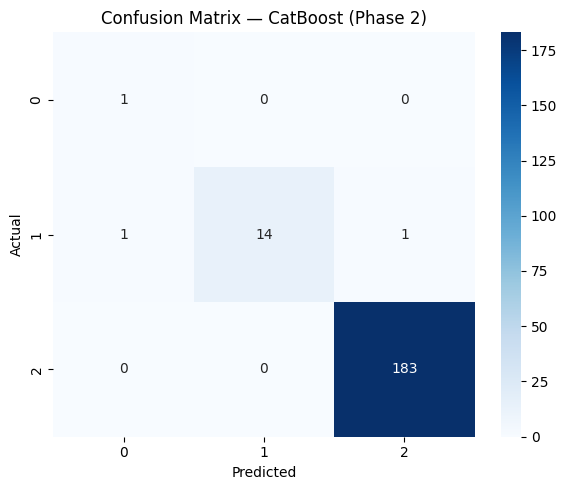


--- Stacking Ensemble (Phase 2) ---

  TEST SET RESULTS — Stacking Ensemble (Phase 2)
  Accuracy         : 0.9800
  Balanced Accuracy: 0.9167
  F1 Macro         : 0.7515
  F1 Weighted      : 0.9831
  MCC              : 0.8716
  AUC-ROC (OvR)    : 0.9633

Classification Report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.75      0.86        16
           2       0.99      1.00      1.00       183

    accuracy                           0.98       200
   macro avg       0.75      0.92      0.75       200
weighted avg       0.99      0.98      0.98       200



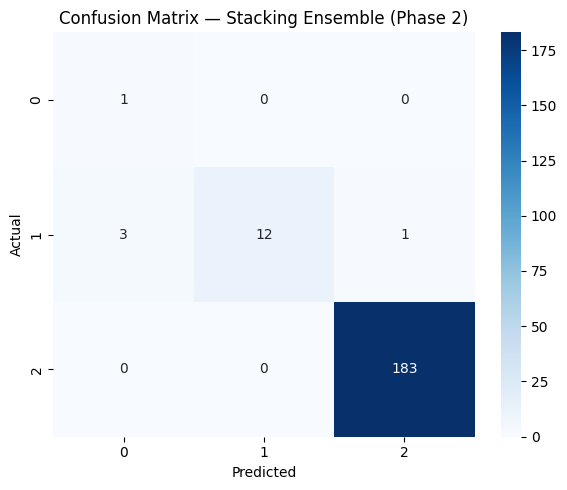

In [28]:
# ── Final test-set evaluation (Phase 2) ───────────────────────────────────
best_single_p2_name = phase2_df.iloc[0]['Model']
best_single_clf_p2  = balanced_clfs[best_single_p2_name]

best_single_pipe_p2 = Pipeline([
    ('scaler', RobustScaler()),
    ('clf'   , best_single_clf_p2)
])
best_single_pipe_p2.fit(X_train, y_train)

print(f"\n--- Best Single Model: {best_single_p2_name} ---")
evaluate_on_test(best_single_pipe_p2, X_test, y_test,
                 label=f"{best_single_p2_name} (Phase 2)")

print("\n--- Stacking Ensemble (Phase 2) ---")
evaluate_on_test(stack_pipe_p2, X_test, y_test,
                 label="Stacking Ensemble (Phase 2)")

---
## 6. Phase 1 vs Phase 2 — Final Comparison

In [29]:
# ── Merge results for side-by-side comparison ─────────────────────────────
p1 = phase1_df[['Model','F1_Macro','Bal_Accuracy']].copy()
p1.columns = ['Model','P1_F1_Macro','P1_Bal_Acc']

p2 = phase2_df[['Model','F1_Macro','Bal_Accuracy']].copy()
p2.columns = ['Model','P2_F1_Macro','P2_Bal_Acc']

compare_df = p1.merge(p2, on='Model')
compare_df['Delta_F1']  = compare_df['P1_F1_Macro'] - compare_df['P2_F1_Macro']

compare_df.sort_values('P1_F1_Macro', ascending=False, inplace=True)
print(compare_df.round(4).to_string(index=False))

               Model  P1_F1_Macro  P1_Bal_Acc  P2_F1_Macro  P2_Bal_Acc  Delta_F1
            CatBoost       0.7564      0.8622       0.8758      0.9070   -0.1193
   Gradient Boosting       0.7358      0.8505       0.7924      0.7961   -0.0565
             XGBoost       0.7218      0.8219       0.7943      0.7901   -0.0725
            LightGBM       0.7137      0.8390       0.8623      0.8625   -0.1486
         Extra Trees       0.7104      0.7987       0.5864      0.5471    0.1240
       Random Forest       0.6949      0.8169       0.7613      0.7534   -0.0663
       Decision Tree       0.6838      0.7836       0.7531      0.8198   -0.0693
MLP (Neural Network)       0.6405      0.7751       0.6063      0.6053    0.0343
                 SVM       0.6305      0.7860       0.6327      0.7788   -0.0022
         Naive Bayes       0.6156      0.7765       0.6236      0.8093   -0.0081
 Logistic Regression       0.6048      0.8575       0.6235      0.8452   -0.0186
          Extra Tree       0

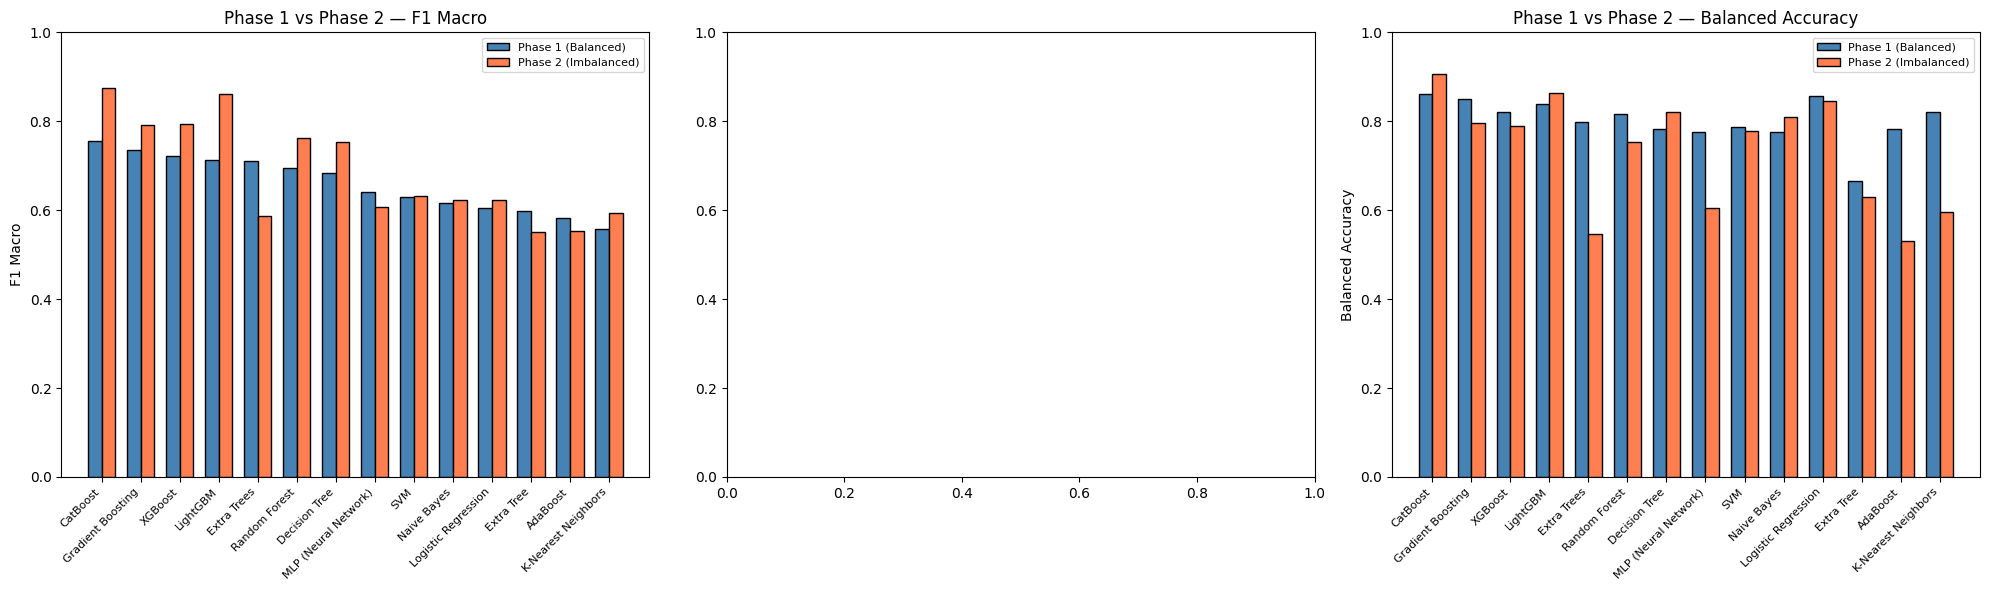

In [30]:
# ── Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(compare_df))
w = 0.35

for ax, col_p1, col_p2, ylabel in [
    (axes[0], 'P1_F1_Macro', 'P2_F1_Macro', 'F1 Macro'),
    (axes[2], 'P1_Bal_Acc' , 'P2_Bal_Acc' , 'Balanced Accuracy'),
]:
    ax.bar(x - w/2, compare_df[col_p1], w, label='Phase 1 (Balanced)',
           color='steelblue', edgecolor='black')
    ax.bar(x + w/2, compare_df[col_p2], w, label='Phase 2 (Imbalanced)',
           color='coral', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df['Model'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.set_title(f"Phase 1 vs Phase 2 — {ylabel}")

plt.tight_layout(); plt.show()

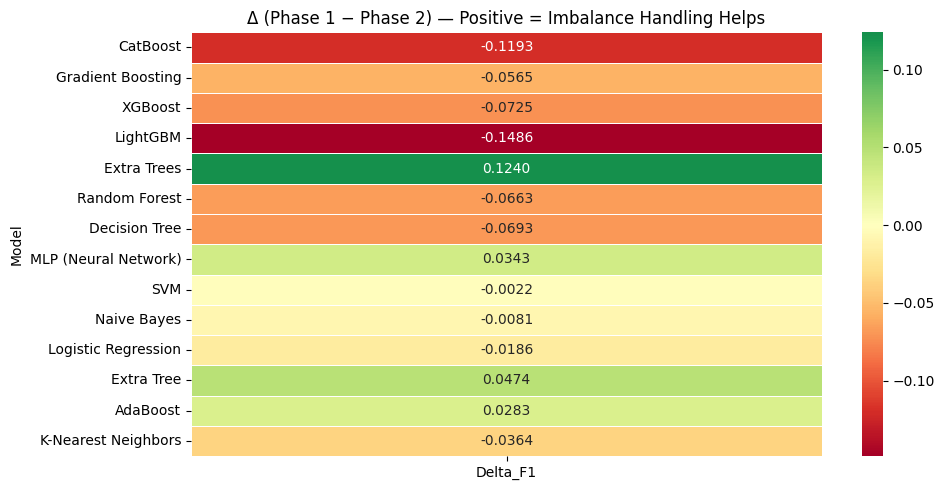

In [32]:
# ── Delta heatmap ─────────────────────────────────────────────────────────
delta_df = compare_df[['Model','Delta_F1']].set_index('Model')

plt.figure(figsize=(10, 5))
sns.heatmap(delta_df, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title("Δ (Phase 1 − Phase 2) — Positive = Imbalance Handling Helps")
plt.tight_layout(); plt.show()

In [ ]:
# ── Summary printout ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("  FINAL SUMMARY")
print("="*65)
print(f"  Phase 1 Best CV Model : {phase1_df.iloc[0]['Model']}")
print(f"    CV F1 Macro         : {phase1_df.iloc[0]['F1_Macro']:.4f}")
print()
print(f"  Phase 2 Best CV Model : {phase2_df.iloc[0]['Model']}")
print(f"    CV F1 Macro         : {phase2_df.iloc[0]['F1_Macro']:.4f}")
print()
avg_delta = compare_df['Delta_F1'].mean()
print(f"  Average ΔF1 (P1−P2)   : {avg_delta:+.4f}")
verdict = " Imbalance handling consistently improves results." \
          if avg_delta > 0 else \
          "Models are robust to imbalance without explicit handling."
print(f"  Verdict               : {verdict}")
print("="*65)


  FINAL SUMMARY
  Phase 1 Best CV Model : CatBoost
    CV F1 Macro         : 0.7564

  Phase 2 Best CV Model : CatBoost
    CV F1 Macro         : 0.8758

  Average ΔF1 (P1−P2)   : -0.0260
  Verdict               : Models are robust to imbalance without explicit handling.
